In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.utils import resample



In [2]:
#Loading the dataset
df = pd.read_pickle("dataframes\\final_df.pkl")

In [16]:
df = df[~((df['video_id'] == "vid3_seg5") & (df['agent_id'] == 14))]

In [17]:
camera_kp_totals = (
    df.groupby(['video_id','agent_id', 'camera_id'])['num_kp']
    .sum()
    .reset_index()
)

display(camera_kp_totals[(camera_kp_totals['video_id'] == "vid3_seg5") & (camera_kp_totals['agent_id'] == 2)])

camera_kp_totals = camera_kp_totals.loc[
    camera_kp_totals.groupby(['video_id', 'agent_id'])['num_kp'].idxmax()
]

key_columns = ['video_id', 'agent_id', 'camera_id']

df = df.merge(camera_kp_totals[key_columns], on=key_columns, how='inner')

,video_id,agent_id,camera_id,num_kp
416,vid3_seg5,2,cam6,122343
417,vid3_seg5,2,cam8,143900


In [18]:
df['keypoints'] = df['keypoints'].apply(lambda x: np.array(x))
df['occluded'] = df['occluded'].apply(lambda x: np.array(x))
display(df)

,video_id,camera_id,frame_id,agent_id,num_kp,keypoints,occluded,is_laughing_no_audio,is_laughing_only_audio,is_laughing_with_audio
0,vid2_seg9,cam2,0,4,17,"[[0.4309090909090909, 0.5925925925925926], [0....","[0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, ...",0.0,0.0,0.0
1,vid2_seg9,cam2,0,27,17,"[[0.6454545454545455, 0.2878787878787879], [0....","[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, ...",0.0,0.0,0.0
2,vid2_seg9,cam2,0,26,17,"[[0.7654545454545455, 0.35353535353535354], [0...","[0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, ...",0.0,0.0,0.0
3,vid2_seg9,cam2,0,28,17,"[[0.6809090909090909, 0.5286195286195287], [0....","[0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, ...",0.0,0.0,0.0
4,vid2_seg9,cam2,0,13,17,"[[0.14360509125801596, 0.0], [0.20105184809690...","[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2278443,vid3_seg6,cam8,7193,12,18,"[[0.14468534792981796, 0.7366877053412233], [0...","[0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, ...",0.0,0.0,0.0
2278444,vid3_seg6,cam8,7193,45,18,"[[0.6967741755567549, 0.9972923913041981], [0....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.0,0.0,0.0
2278445,vid3_seg6,cam8,7193,46,19,"[[0.6758328751984918, 0.6272563004130477], [0....","[0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, ...",0.0,0.0,0.0
2278446,vid3_seg6,cam8,7194,31,1,"[[None, None], [None, None], [None, None], [No...","[None, None, None, None, None, None, None, Non...",0.0,0.0,0.0


In [28]:
def add_segment(visible_kps, total_kps, ot, segment, segments, segment_keypoints, video_id, agent_id, current_label):
    if visible_kps / total_kps >= (1 - ot):
        keypoints = np.stack(segment['keypoints'].values)  # shape: (frames, 17, 2)
        n_frames = len(segment)
        max_len = 600
        min_len = 100

        if n_frames <= max_len:
            # Keep as is
            segments.append({
                'video_id': video_id,
                'agent_id': agent_id,
                'start_frame': segment.iloc[0]['frame_id'],
                'end_frame': segment.iloc[-1]['frame_id'],
                'label': current_label,
                'length': n_frames
            })
            segment_keypoints.append(keypoints)
        else:
            # Randomized splitting
            start = 0
            while start < n_frames:
                chunk_len = random.randint(min_len, max_len)
                end = min(start + chunk_len, n_frames)
                subseg = segment.iloc[start:end]
                keypoints_sub = np.stack(subseg['keypoints'].values)

                segments.append({
                    'video_id': video_id,
                    'agent_id': agent_id,
                    'start_frame': subseg.iloc[0]['frame_id'],
                    'end_frame': subseg.iloc[-1]['frame_id'],
                    'label': current_label,
                    'length': len(subseg)
                })
                segment_keypoints.append(keypoints_sub)

                start = end

def stop_episode(group, i, ann_column, current_label):
    default_stop = group.loc[i, ann_column] != current_label or group.loc[i, 'frame_id'] - group.loc[i-1, 'frame_id'] > 1
    if not default_stop: return False
    if current_label == 0: return True

    for j in range(30):
        if i + j >= len(group):
            break
        if group.loc[i + j, ann_column] == current_label:
            return False
    return True

def segment (data_frame, ann_column, occlusion_threshold):
    segments = []
    segment_keypoints = []

    for (video_id, agent_id), group in data_frame.groupby(['video_id', 'agent_id']):
        group = group.reset_index(drop=True)
        current_label = group.loc[0, ann_column]
        start_idx = 0
        for i in range(1, len(group)):
            if stop_episode(group, i, ann_column, current_label):

                segment = group.iloc[start_idx:i]
                total_kps = len(segment) * 17
                visible_kps = sum(segment["num_kp"])
                add_segment (visible_kps, total_kps, occlusion_threshold, segment, segments, segment_keypoints, video_id, agent_id, current_label)

                start_idx = i
                current_label = group.loc[i, ann_column]
        segment = group.iloc[start_idx:]
        total_kps = len(segment) * 17
        visible_kps = sum(segment["num_kp"])
        add_segment (visible_kps, total_kps, occlusion_threshold, segment, segments, segment_keypoints, video_id, agent_id, current_label)
    return segments, segment_keypoints



In [29]:
sna, skna = segment(df, "is_laughing_no_audio", 0.3)
swa, skwa = segment(df, "is_laughing_with_audio", 0.3)
sao, skao = segment(df, "is_laughing_only_audio", 0.3)

In [50]:
def print_statistics(sd):
    sdf = pd.DataFrame(sd)

    print(sdf.head())

    # Summary statistics
    print("\n--- Segment Length Stats ---")
    print(sdf['length'].describe())

    laughter_segments = sdf[(sdf['label'] == 1)]
    non_laughter_segments = sdf[(sdf['label'] == 0)]
    mean_lenght_all = sdf['length'].mean()
    mean_laughter_segments = laughter_segments['length'].mean()
    mean_nonlaughter_segments = non_laughter_segments['length'].mean()
    print("\n--- Segment Length Stats ---")
    print(f"Mean of all: {mean_lenght_all}")
    print(f"Mean of laughter: {mean_laughter_segments}")
    print(f"Mean of nonlaughter: {mean_nonlaughter_segments}")
# Plot histogram of segment lengths (laughing only) in red
    plt.figure(figsize=(10, 5))
    sns.histplot(laughter_segments['length'], bins=30, kde=True, color='red')
    plt.title("Histogram of Laughing Segment Lengths < 1000 Frames")
    plt.xlabel("Segment Length (frames)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot histogram of segment lengths
    plt.figure(figsize=(10, 5))
    sns.histplot(sdf['length'], bins=30, kde=True)
    plt.title("Histogram of Segment Lengths (in Frames)")
    plt.xlabel("Segment Length (frames)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    short_segments = sdf[sdf['length'] < 1000]
    sns.histplot(short_segments['length'], bins=30, kde=True)
    plt.title("Histogram of Segment Lengths < 1000 Frames")
    plt.xlabel("Segment Length (frames)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot class distribution
    plt.figure(figsize=(6, 4))
    sns.countplot(x='label', data=sdf)
    plt.title("Laughter vs Non-Laughter Segment Distribution")
    plt.xlabel("Label (0 = No Laugh, 1 = Laugh)")
    plt.ylabel("Segment Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    label_plot_data = sdf['label'].copy()
    label_plot_data = label_plot_data.fillna("NaN")

    plt.figure(figsize=(6, 4))
    sns.countplot(x=label_plot_data)
    plt.title("Laughter vs Non-Laughter Segment Distribution (Including NaNs)")
    plt.xlabel("Label (0 = No Laugh, 1 = Laugh, NaN = Missing)")
    plt.ylabel("Segment Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    video_id  agent_id  start_frame  end_frame  label  length
0  vid2_seg8         1            0        417    0.0     418
1  vid2_seg8         1          418        930    0.0     513
2  vid2_seg8         1          931       1522    0.0     592
3  vid2_seg8         1         1523       1811    0.0     289
4  vid2_seg8         1         1812       2325    0.0     514

--- Segment Length Stats ---
count    7092.000000
mean      311.311337
std       162.346996
min         1.000000
25%       177.000000
50%       304.000000
75%       450.000000
max       600.000000
Name: length, dtype: float64

--- Segment Length Stats ---
Mean of all: 311.3113367174281
Mean of laughter: 64.44136460554371
Mean of nonlaughter: 328.7931451004077


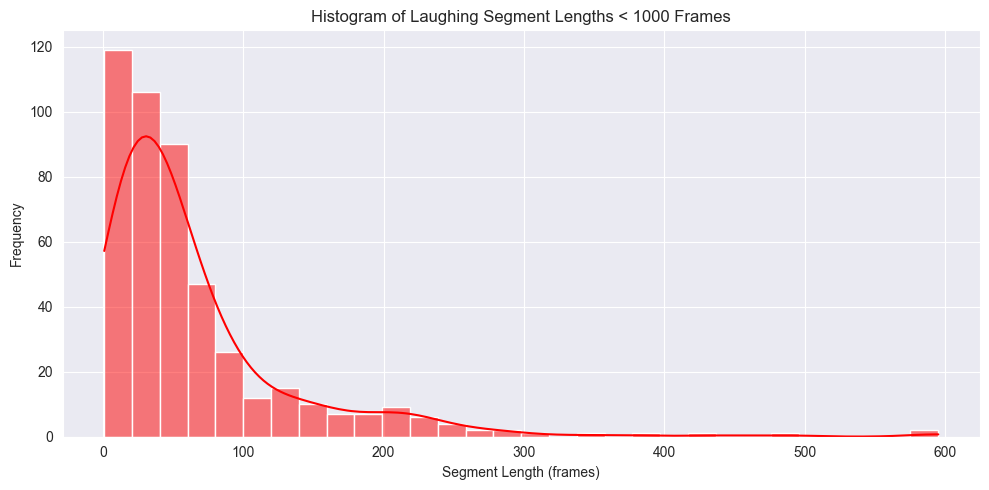

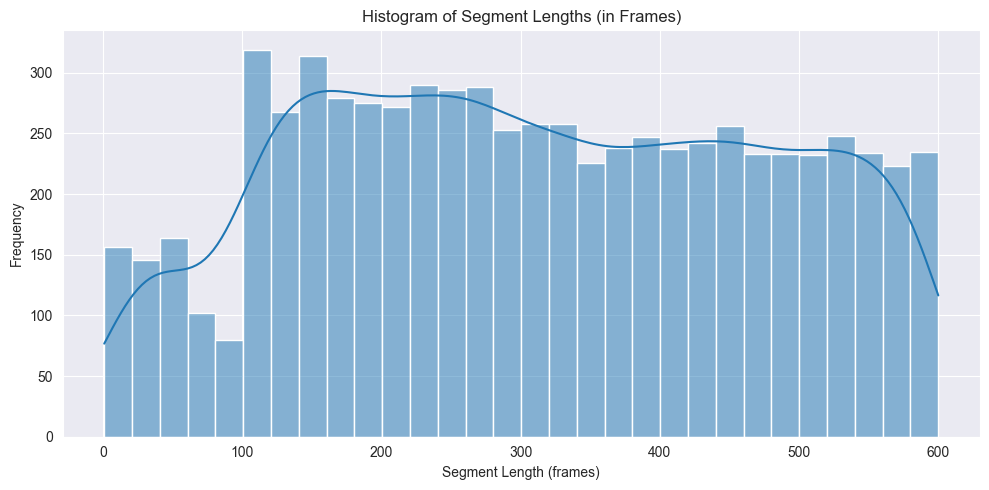

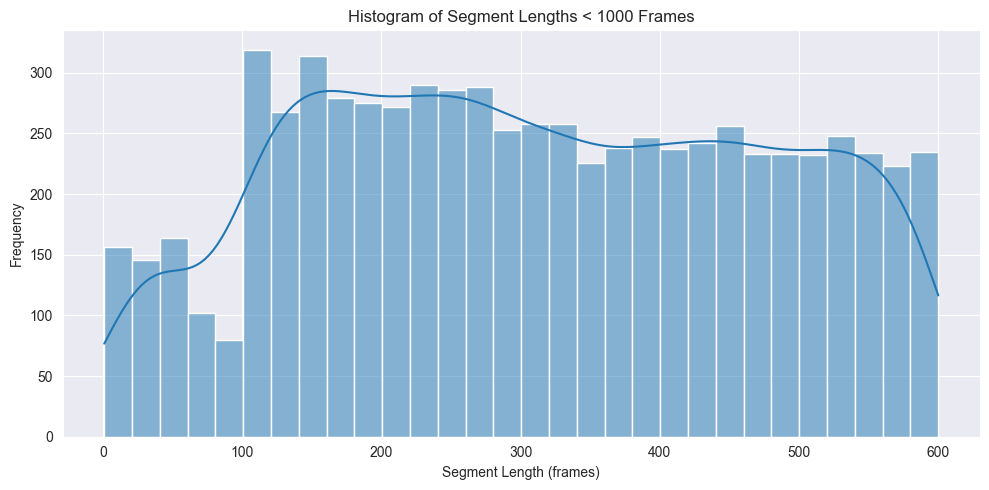

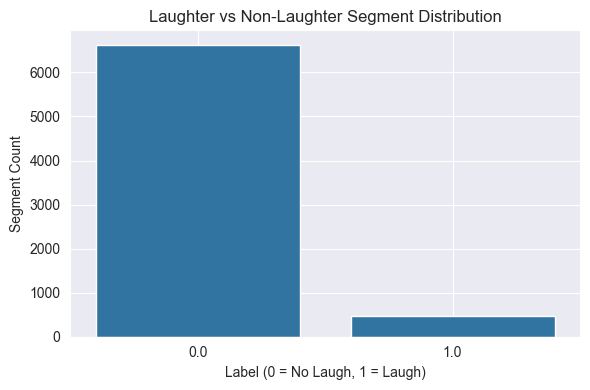

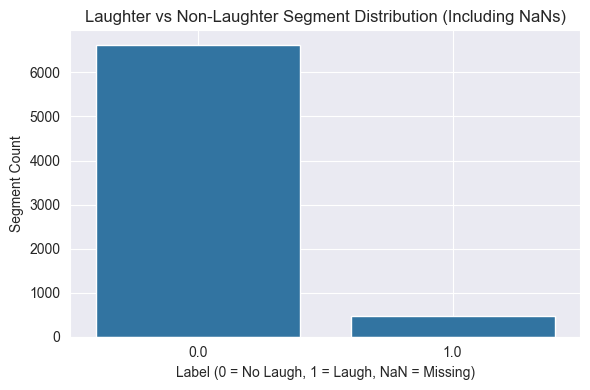

    video_id  agent_id  start_frame  end_frame  label  length
0  vid2_seg8         1            0        390    0.0     391
1  vid2_seg8         1          391        506    0.0     116
2  vid2_seg8         1          507        667    0.0     161
3  vid2_seg8         1          668       1204    0.0     537
4  vid2_seg8         1         1205       1468    0.0     264

--- Segment Length Stats ---
count    7065.000000
mean      312.501062
std       162.782283
min         1.000000
25%       176.000000
50%       310.000000
75%       451.000000
max       600.000000
Name: length, dtype: float64

--- Segment Length Stats ---
Mean of all: 312.50106157112526
Mean of laughter: 53.05357142857143
Mean of nonlaughter: 330.06679764243614


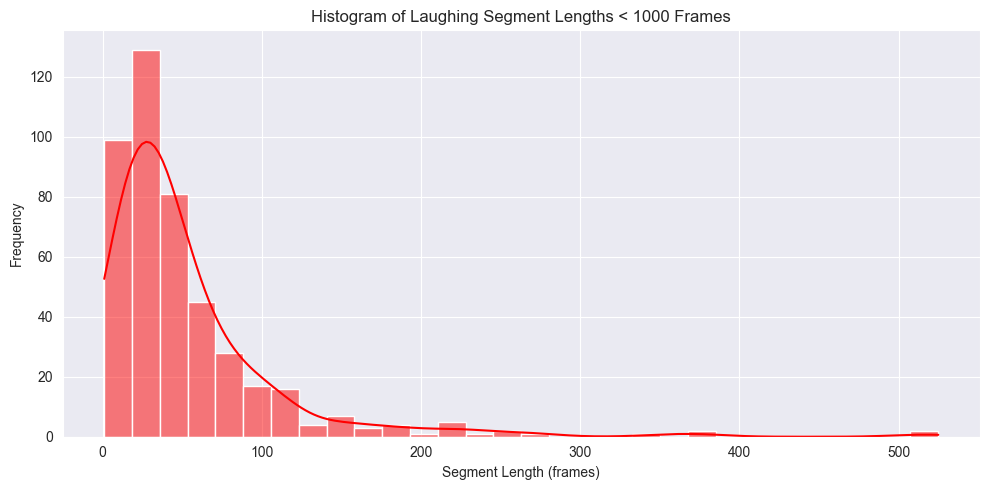

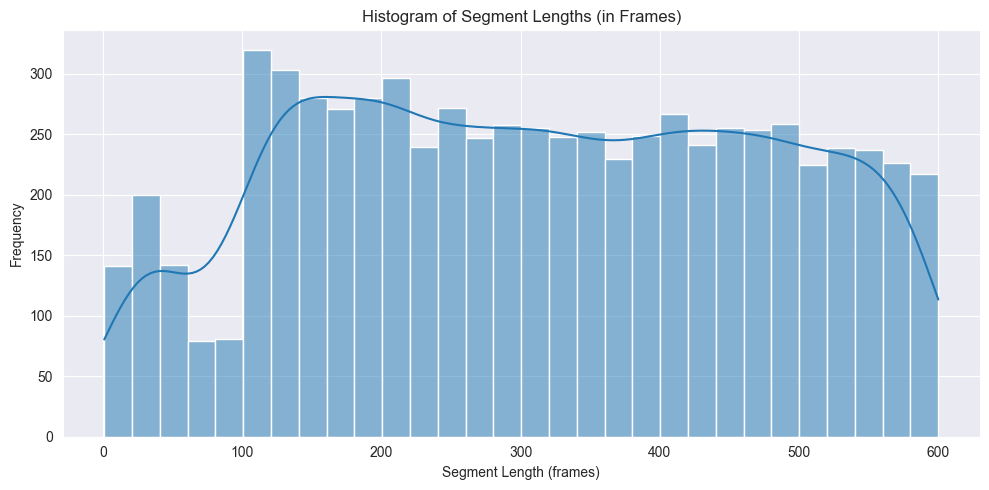

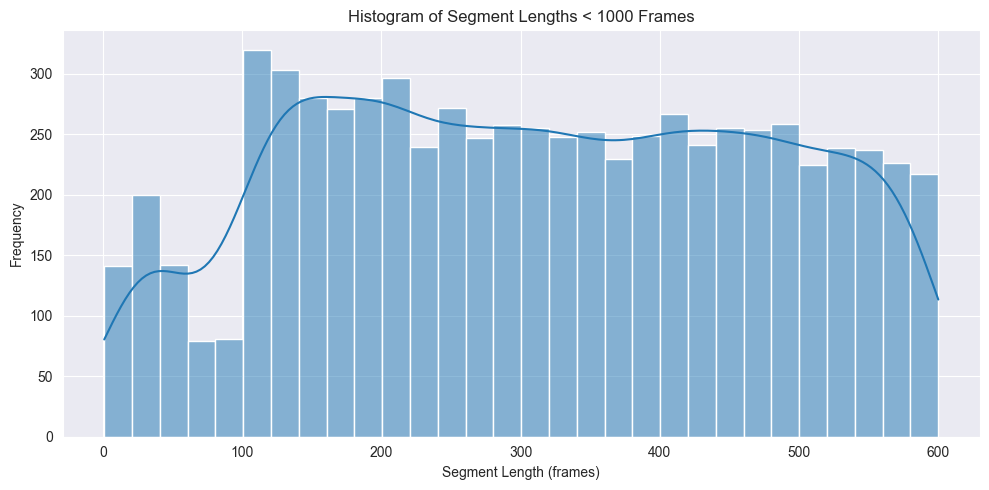

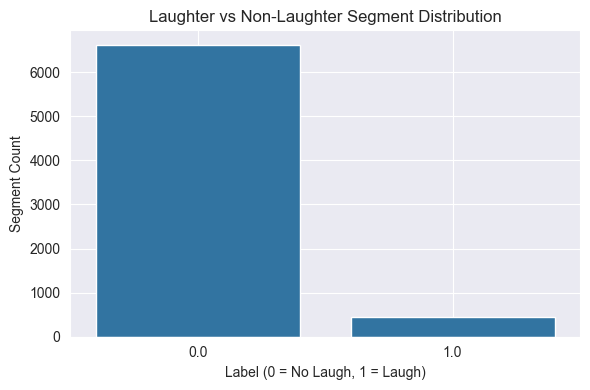

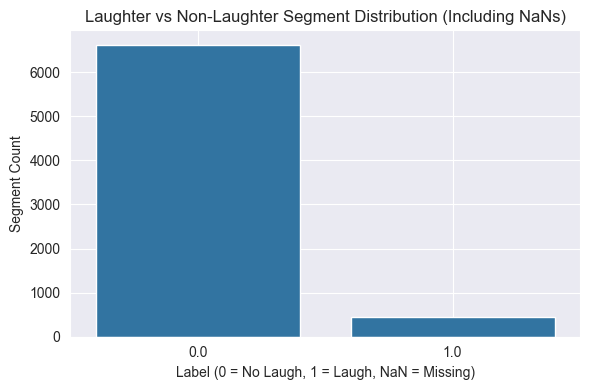

    video_id  agent_id  start_frame  end_frame  label  length
0  vid2_seg8         1            0        431    0.0     432
1  vid2_seg8         1          432        604    0.0     173
2  vid2_seg8         1          605       1053    0.0     449
3  vid2_seg8         1         1054       1224    0.0     171
4  vid2_seg8         1         1225       1396    0.0     172

--- Segment Length Stats ---
count    7349.000000
mean      300.424548
std       164.965774
min         1.000000
25%       163.000000
50%       297.000000
75%       439.000000
max       600.000000
Name: length, dtype: float64

--- Segment Length Stats ---
Mean of all: 300.4245475574908
Mean of laughter: 47.1968
Mean of nonlaughter: 323.9622248661511


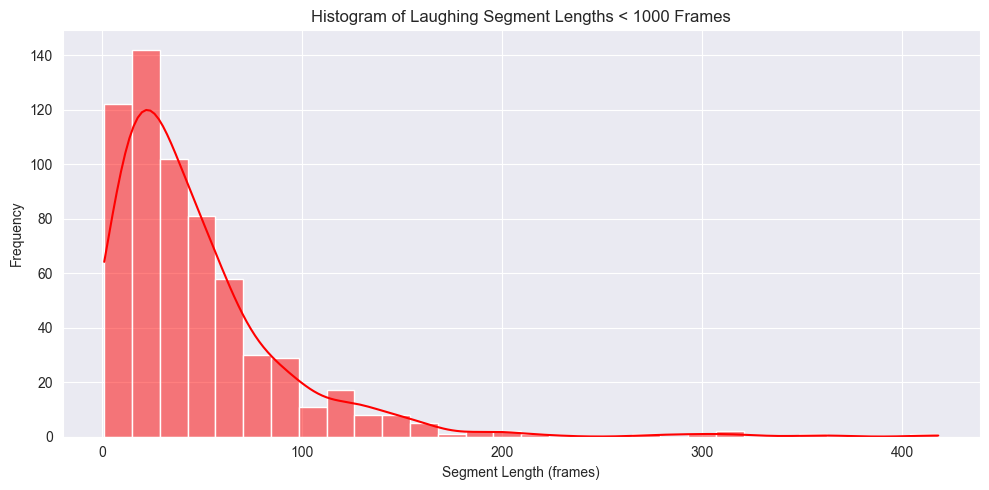

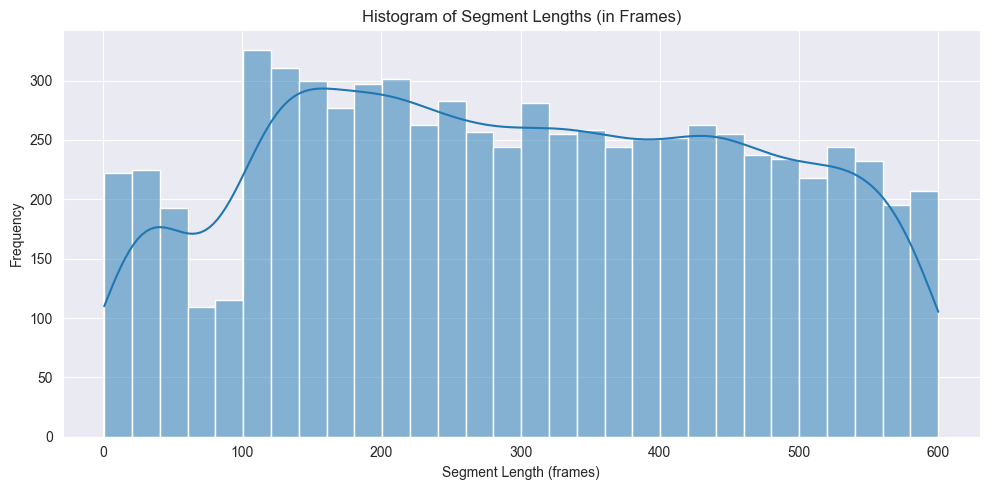

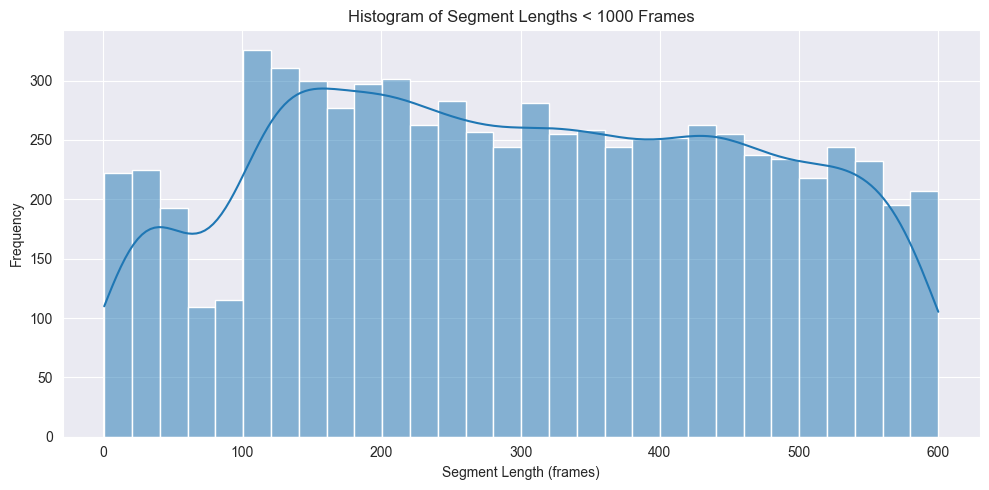

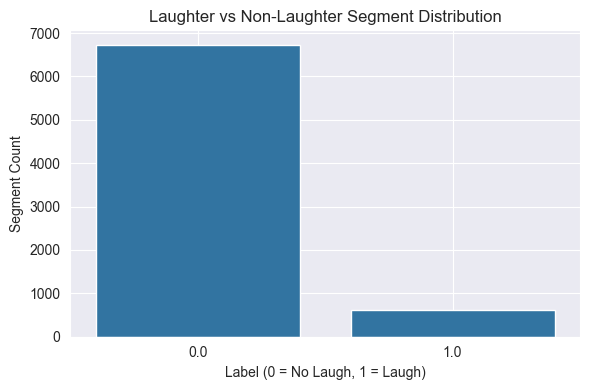

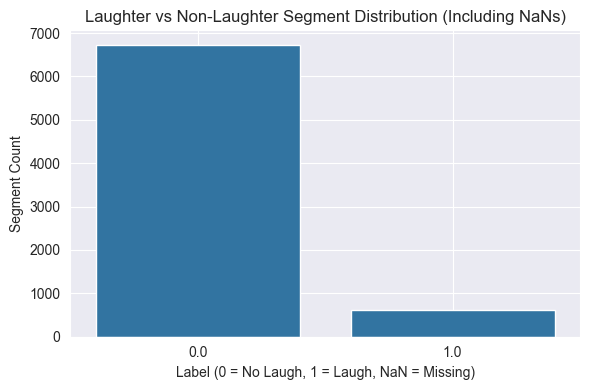

In [51]:
print_statistics(sna)
print_statistics(swa)
print_statistics(sao)

In [48]:
def remove_excess_segments(segments):
    df_segments = pd.DataFrame(segments)
    balanced_segments = []
    for agent_id, group in df_segments.groupby('agent_id'):
        laughs = group[group['label'] == 1]
        no_laughs = group[group['label'] == 0]

        num_laughs = len(laughs)
        desired_no_laughs = int(1.5 * num_laughs)
        desired_no_laughs = desired_no_laughs if desired_no_laughs != 0 else 60

        if len(no_laughs) == 0:
            # Only laughs available
            balanced_segments.append(laughs)
            continue
        sampled_no_laughs = resample(
            no_laughs, replace=False,
            n_samples=min(len(no_laughs), desired_no_laughs),
            random_state=42
        )

        balanced_group = pd.concat([laughs, sampled_no_laughs])
        balanced_segments.append(balanced_group)

    df_balanced = pd.concat(balanced_segments).reset_index(drop=True)
    return df_balanced

In [52]:
fsna = remove_excess_segments(sna)
fswa = remove_excess_segments(swa)
fsao = remove_excess_segments(sao)

    video_id  agent_id  start_frame  end_frame  label  length
0  vid2_seg8         1         4071       4190    1.0     120
1  vid2_seg8         1         4262       4268    1.0       7
2  vid2_seg8         1         5889       5966    1.0      78
3  vid3_seg1         1         1976       2117    1.0     142
4  vid3_seg3         1         5311       5367    1.0      57

--- Segment Length Stats ---
count    1184.000000
mean      220.073480
std       181.164801
min         1.000000
25%        51.000000
50%       178.000000
75%       366.250000
max       600.000000
Name: length, dtype: float64

--- Segment Length Stats ---
Mean of all: 220.07347972972974
Mean of laughter: 64.44136460554371
Mean of nonlaughter: 322.15944055944055


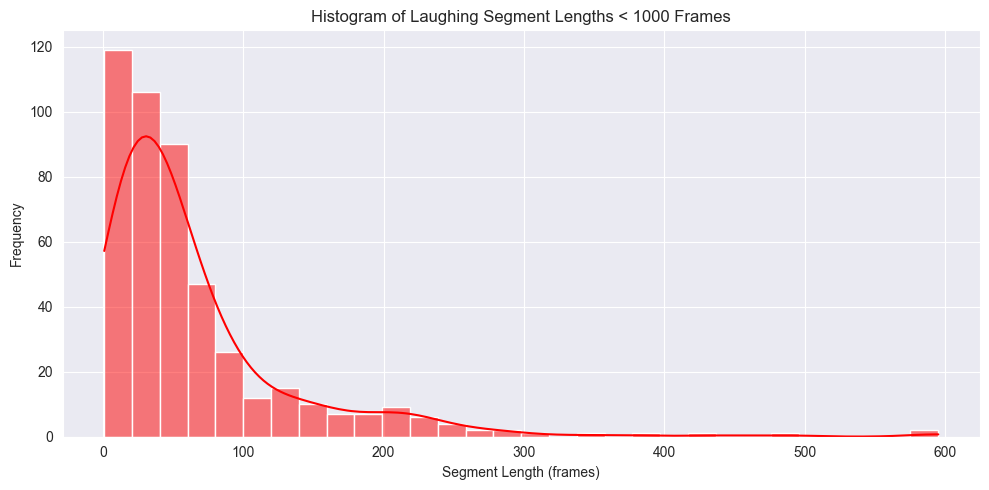

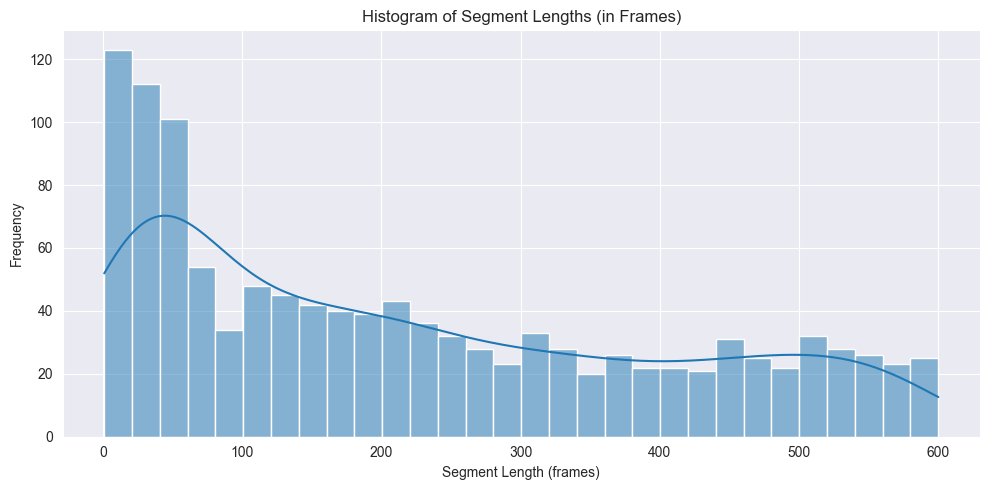

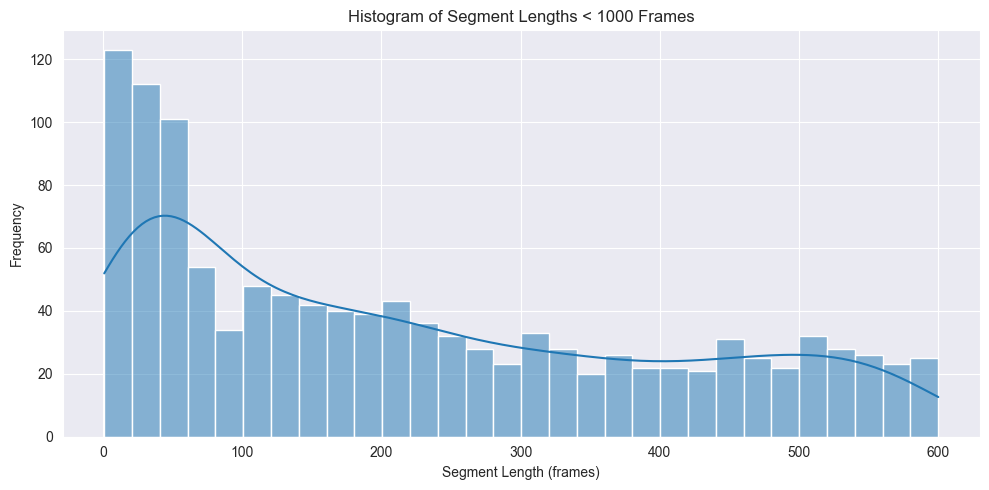

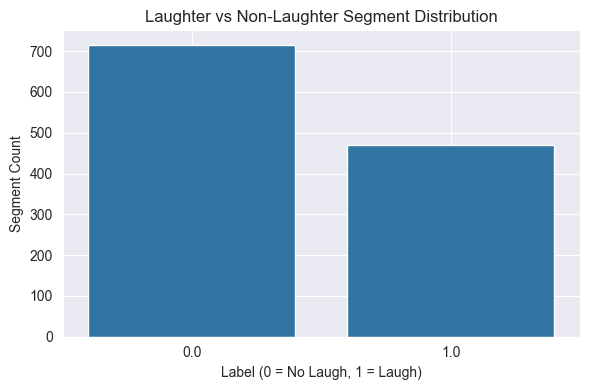

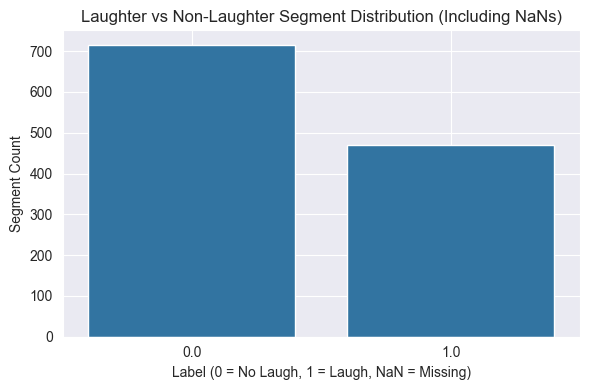

    video_id  agent_id  start_frame  end_frame  label  length
0  vid2_seg8         1         4115       4482    1.0     368
1  vid2_seg8         1         5877       5943    1.0      67
2  vid2_seg9         1          371        388    1.0      18
3  vid3_seg1         1          651        659    1.0       9
4  vid3_seg1         1          736        759    1.0      24

--- Segment Length Stats ---
count    1132.000000
mean      214.463781
std       183.791244
min         1.000000
25%        44.000000
50%       158.000000
75%       375.000000
max       600.000000
Name: length, dtype: float64

--- Segment Length Stats ---
Mean of all: 214.4637809187279
Mean of laughter: 53.05357142857143
Mean of nonlaughter: 320.1827485380117


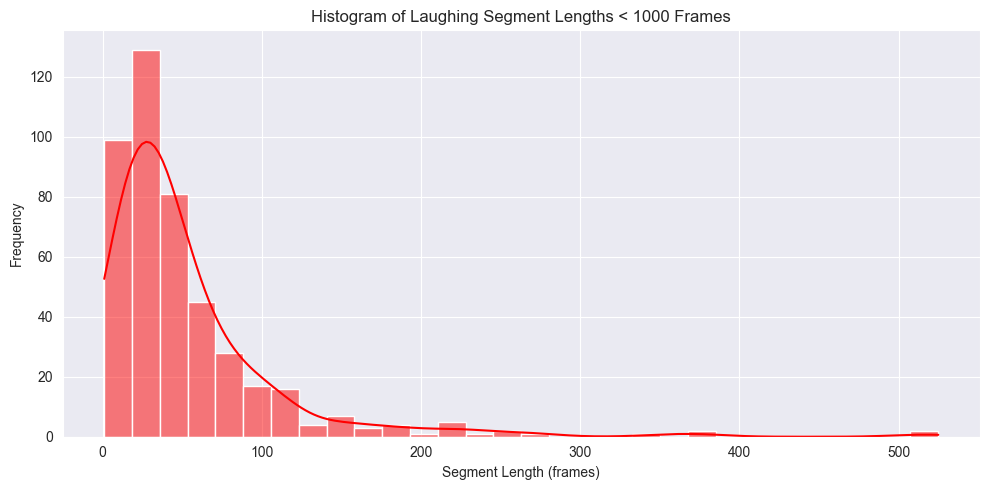

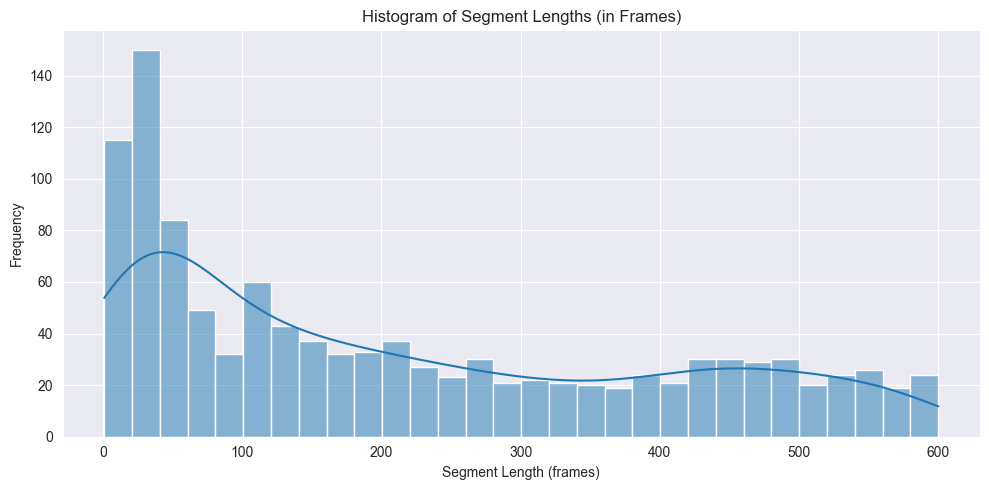

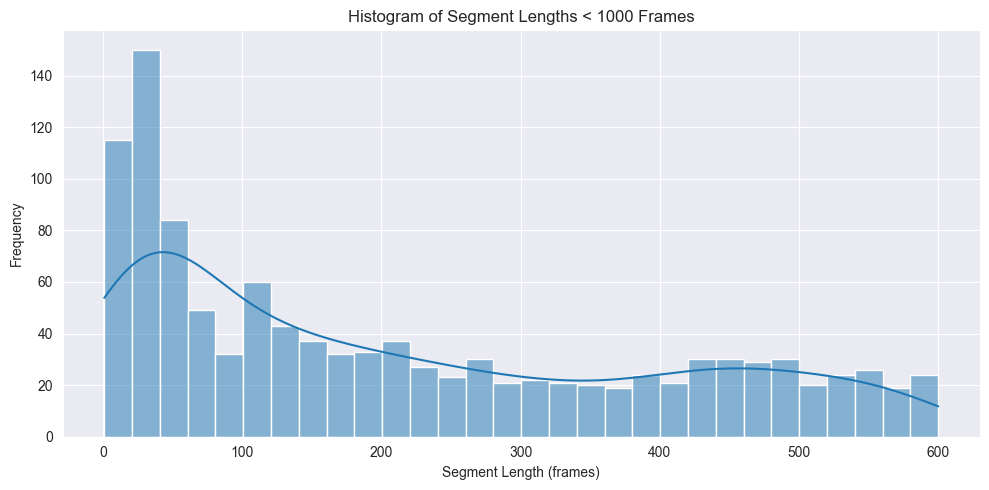

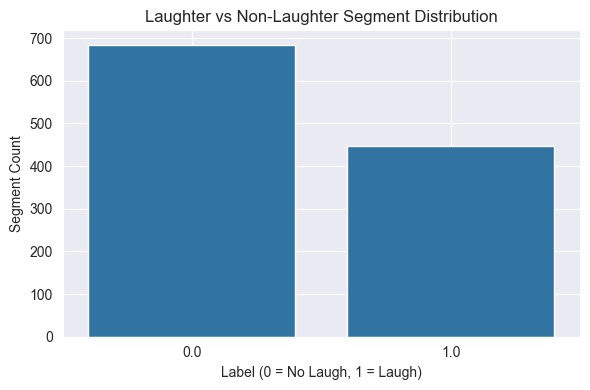

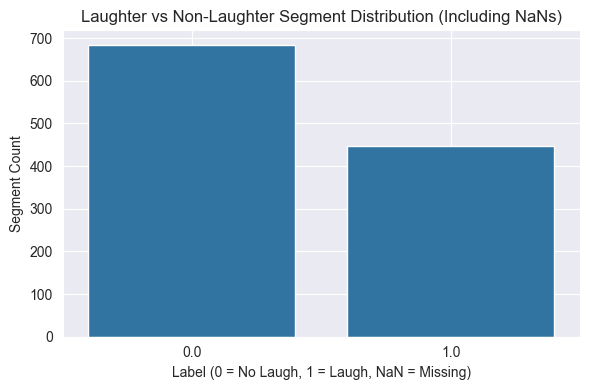

    video_id  agent_id  start_frame  end_frame  label  length
0  vid2_seg8         1         2935       2954    1.0      20
1  vid2_seg8         1         3999       4416    1.0     418
2  vid2_seg8         1         5817       5861    1.0      45
3  vid2_seg8         1         5926       5949    1.0      24
4  vid2_seg8         1         6588       6598    1.0      11

--- Segment Length Stats ---
count    1573.000000
mean      210.466624
std       179.638143
min         1.000000
25%        44.000000
50%       158.000000
75%       357.000000
max       599.000000
Name: length, dtype: float64

--- Segment Length Stats ---
Mean of all: 210.4666242848061
Mean of laughter: 47.1968
Mean of nonlaughter: 318.10759493670884


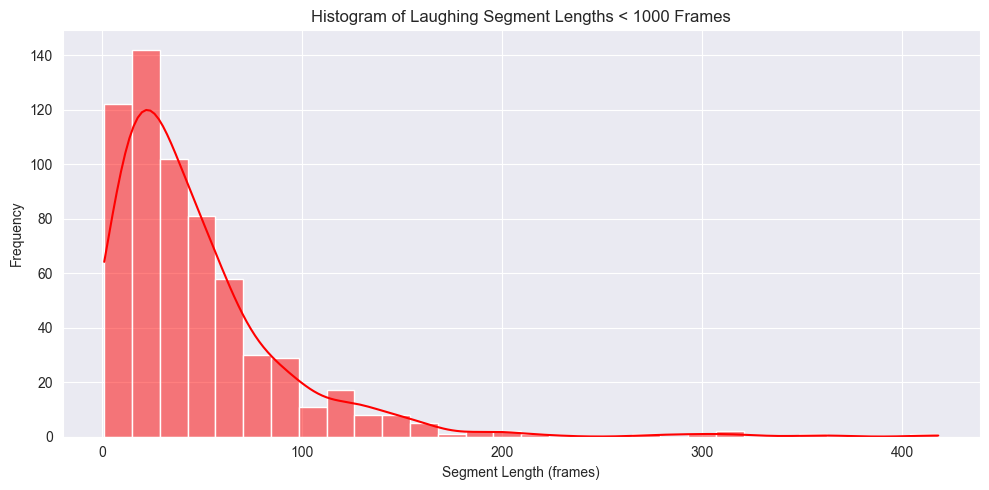

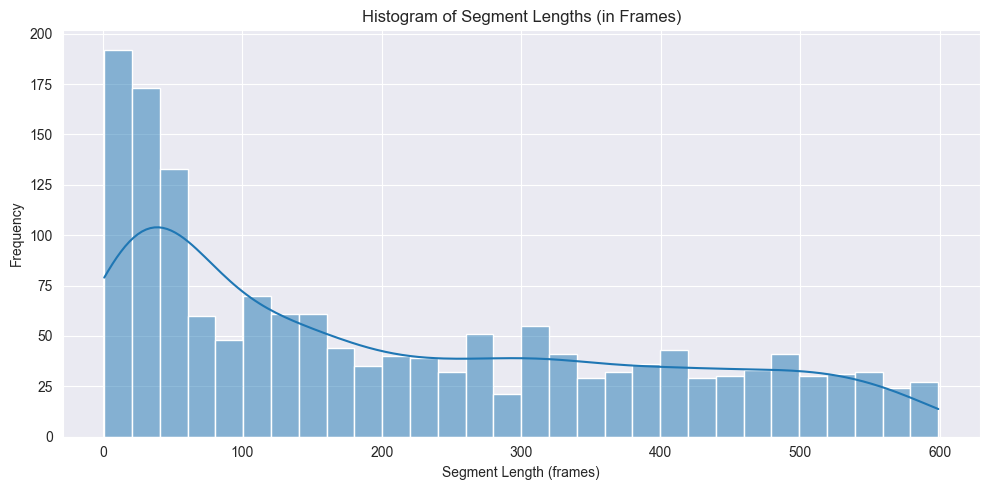

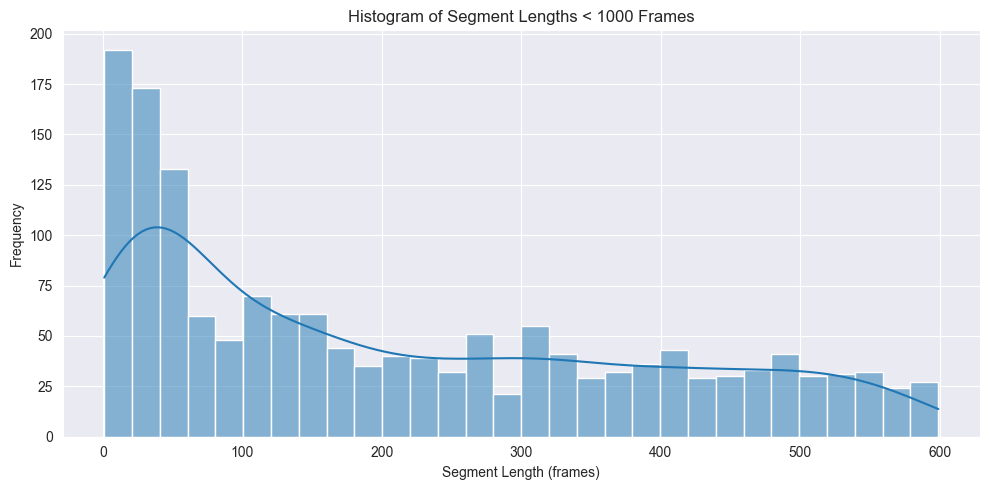

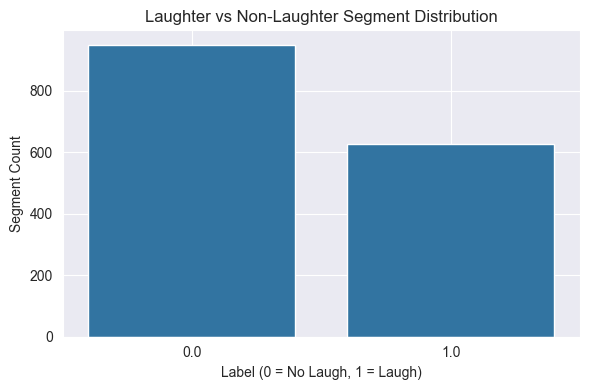

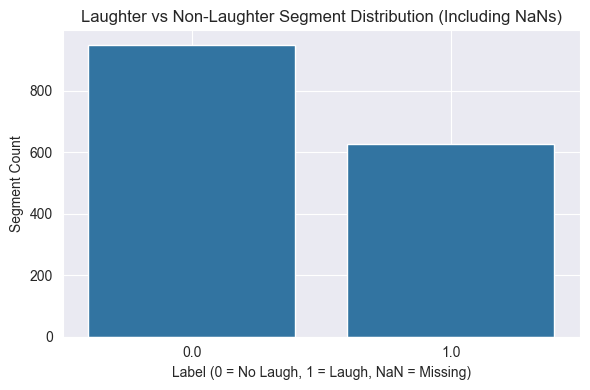

In [54]:
print_statistics(fsna)
print_statistics(fswa)
print_statistics(fsao)

In [56]:
#upload dfs to files
pd.DataFrame(fsna).to_csv("csvs//fsna.csv")
pd.DataFrame(fswa).to_csv("csvs//fswa.csv")
pd.DataFrame(fsao).to_csv("csvs//fsao.csv")
#df.to_csv("csvs//df.csv")